<div style="background:linear-gradient(90deg,#0D47A1,#1E88E5);padding:28px 22px;border-radius:12px;margin-bottom:10px">
<h1 style="color:#ffffff;text-align:center;font-family:Segoe UI, sans-serif;margin:0;">📱🧒 EDA with Kids Screen Time Data</h1>
<p style="color:#E3F2FD;text-align:center;font-size:15px;margin-top:8px;">Advanced Exploratory Data Analysis, Statistical Testing & Predictive Modeling</p>
</div>

<p style="text-align:center;color:#555;font-family:Segoe UI, sans-serif;">
<b>Author:</b> Neha Bhatt &nbsp;|&nbsp; <b>Project:</b> Python Project – I (Advanced Edition) &nbsp;|&nbsp; <b>Dataset:</b> Kids_Screen_Time.csv
</p>

---

## 📌 <span style="color:#1565C0">Project Overview</span>

Excessive screen time among children is a growing healthcare concern, linked to physical issues (eye strain, poor posture, disrupted sleep) and psychological effects (anxiety, attention problems, reduced social interaction).

**Objective:** Go beyond a standard EDA — apply statistical hypothesis testing, behavioral segmentation (clustering), and predictive modeling to uncover *why* children exceed recommended screen time limits, not just *that* they do.

**This notebook covers (Advanced additions marked ⭐):**
1. Data Loading, Cleaning & Quality Audit
2. Feature Engineering ⭐
3. Univariate Analysis
4. Bivariate & Multivariate Analysis
5. Statistical Hypothesis Testing (Chi-Square, ANOVA, Point-Biserial) ⭐
6. Multi-label Health Impact Analysis ⭐
7. Correlation & Multicollinearity Check ⭐
8. K-Means Behavioral Segmentation (Clustering) ⭐
9. Predictive Modeling — Logistic Regression & Random Forest ⭐
10. Feature Importance & Model Evaluation (ROC-AUC) ⭐
11. Key Insights & Recommendations

## 🛠️ <span style="color:#1565C0">1. Setup & Imports</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)

# ---- Notebook-wide style: blue portfolio theme ----
sns.set_theme(style="whitegrid")
BLUE_PALETTE = ["#0D47A1", "#1565C0", "#1E88E5", "#42A5F5", "#90CAF9", "#BBDEFB"]
sns.set_palette(sns.color_palette(BLUE_PALETTE))
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlecolor"] = "#0D47A1"
plt.rcParams["axes.labelcolor"] = "#0D47A1"
plt.rcParams["font.family"] = "sans-serif"

pd.set_option("display.max_columns", None)
np.random.seed(42)
print("Libraries loaded ✅")

Libraries loaded ✅


## 📂 <span style="color:#1565C0">2. Load Data & Quality Audit</span>

In [2]:
df = pd.read_csv("Kids_Screen_Time.csv")
print("Shape:", df.shape)
df.head()

Shape: (9712, 8)


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   str    
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   str    
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   str    
 7   Urban_or_Rural                     9712 non-null   str    
dtypes: bool(1), float64(2), int64(1), str(4)
memory usage: 540.7 KB


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:\n", df.isna().sum())
print("\nMissing % in Health_Impacts:", round(df['Health_Impacts'].isna().mean()*100, 2), "%")

Duplicate rows: 44

Missing values:
 Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

Missing % in Health_Impacts: 33.13 %


In [5]:
# NaN in Health_Impacts genuinely means 'no reported health impact' -> encode explicitly
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

# Sanity checks on ranges
print(df[['Age','Avg_Daily_Screen_Time_hr','Educational_to_Recreational_Ratio']].describe().T)
print("\nUnique Primary_Device:", df['Primary_Device'].unique())
print("Unique Urban_or_Rural:", df['Urban_or_Rural'].unique())
print("Unique Gender:", df['Gender'].unique())

                                    count       mean       std  min    25%  \
Age                                9712.0  12.979201  3.162437  8.0  10.00   
Avg_Daily_Screen_Time_hr           9712.0   4.352837  1.718232  0.0   3.41   
Educational_to_Recreational_Ratio  9712.0   0.427226  0.073221  0.3   0.37   

                                     50%    75%    max  
Age                                13.00  16.00  18.00  
Avg_Daily_Screen_Time_hr            4.44   5.38  13.89  
Educational_to_Recreational_Ratio   0.43   0.48   0.60  

Unique Primary_Device: <StringArray>
['Smartphone', 'Laptop', 'TV', 'Tablet']
Length: 4, dtype: str
Unique Urban_or_Rural: <StringArray>
['Urban', 'Rural']
Length: 2, dtype: str
Unique Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str


## ⭐ <span style="color:#1565C0">3. Feature Engineering</span>
Engineered features let us analyse patterns that raw columns alone don't reveal — age brackets, screen-time severity tiers, and a health-impact burden score.

In [6]:
# Age groups aligned with developmental stages
bins = [7, 9, 12, 15, 18]
labels = ['8-9 (Child)', '10-12 (Pre-teen)', '13-15 (Early Teen)', '16-18 (Late Teen)']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

# Screen time severity tier
def tier(hr):
    if hr <= 2: return 'Low (<=2hr)'
    elif hr <= 4: return 'Moderate (2-4hr)'
    elif hr <= 6: return 'High (4-6hr)'
    else: return 'Very High (>6hr)'
df['Screen_Time_Tier'] = df['Avg_Daily_Screen_Time_hr'].apply(tier)

# Multi-label health impacts -> list + count (burden score)
df['Health_Impacts_List'] = df['Health_Impacts'].apply(
    lambda x: [] if x == 'None' else [h.strip() for h in x.split(',')]
)
df['Health_Impact_Count'] = df['Health_Impacts_List'].apply(len)
df['Has_Health_Impact'] = df['Health_Impact_Count'] > 0

# Binary encode target for modeling
df['Exceeded_Flag'] = df['Exceeded_Recommended_Limit'].astype(int)

df[['Age','Age_Group','Avg_Daily_Screen_Time_hr','Screen_Time_Tier',
    'Health_Impact_Count','Has_Health_Impact']].head()

,Age,Age_Group,Avg_Daily_Screen_Time_hr,Screen_Time_Tier,Health_Impact_Count,Has_Health_Impact
0,14,13-15 (Early Teen),3.99,Moderate (2-4hr),2,True
1,11,10-12 (Pre-teen),4.61,High (4-6hr),1,True
2,18,16-18 (Late Teen),3.73,Moderate (2-4hr),1,True
3,15,13-15 (Early Teen),1.21,Low (<=2hr),0,False
4,12,10-12 (Pre-teen),5.89,High (4-6hr),2,True


## 📊 <span style="color:#1565C0">4. Univariate Analysis</span>

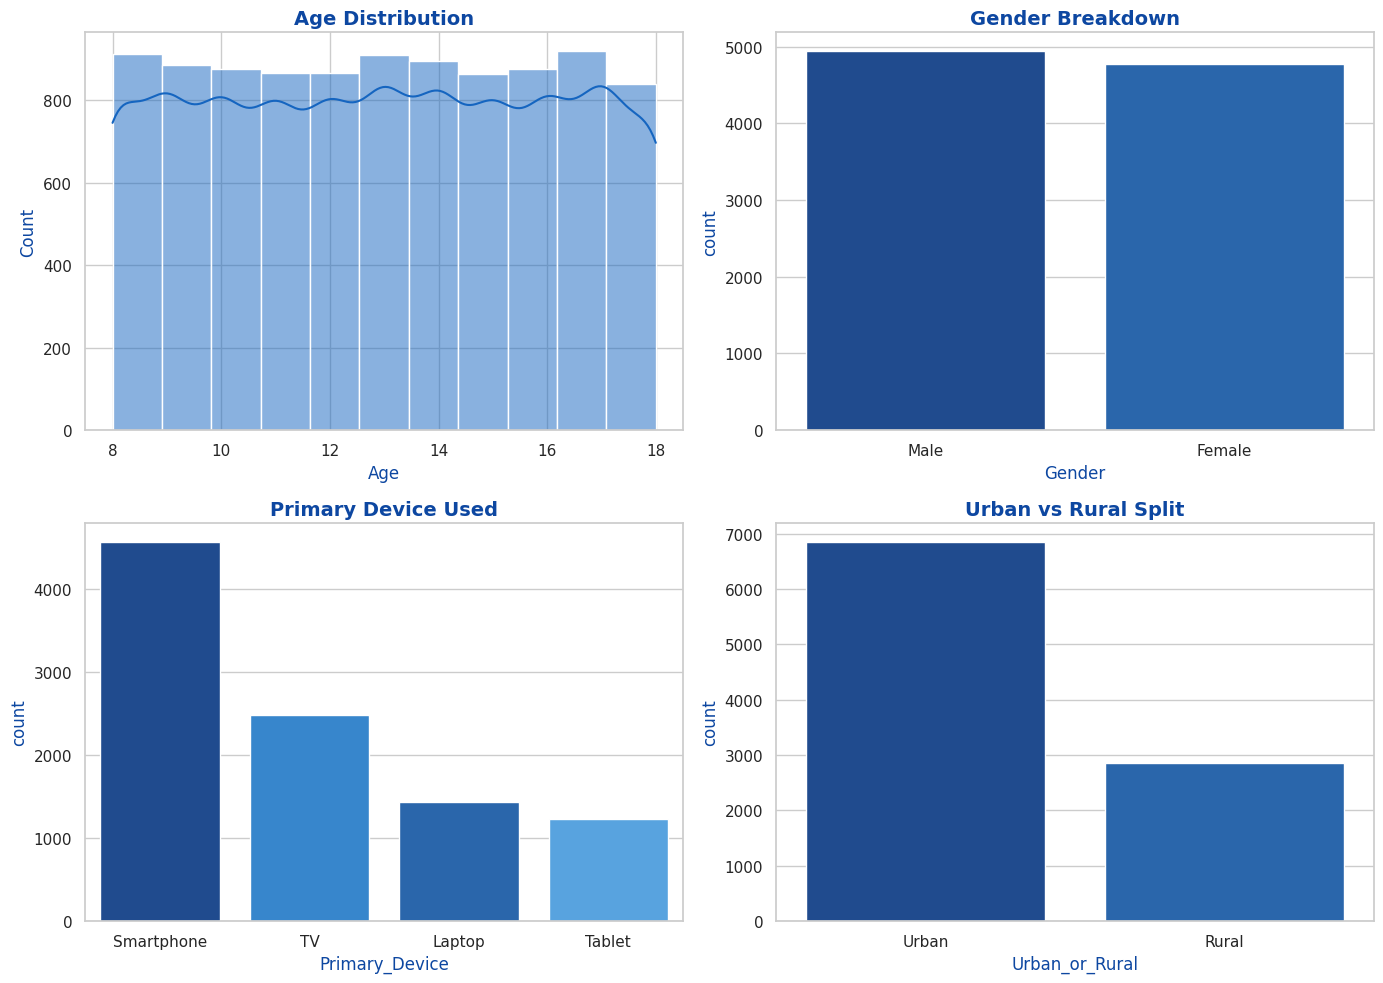

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Age'], bins=11, kde=True, ax=axes[0,0], color=BLUE_PALETTE[1])
axes[0,0].set_title('Age Distribution')

sns.countplot(data=df, x='Gender', ax=axes[0,1], hue='Gender', legend=False)
axes[0,1].set_title('Gender Breakdown')

sns.countplot(data=df, x='Primary_Device', order=df['Primary_Device'].value_counts().index,
              ax=axes[1,0], hue='Primary_Device', legend=False)
axes[1,0].set_title('Primary Device Used')

sns.countplot(data=df, x='Urban_or_Rural', ax=axes[1,1], hue='Urban_or_Rural', legend=False)
axes[1,1].set_title('Urban vs Rural Split')

for ax in axes.flat:
    ax.title.set_color(BLUE_PALETTE[0])
plt.tight_layout()
plt.show()

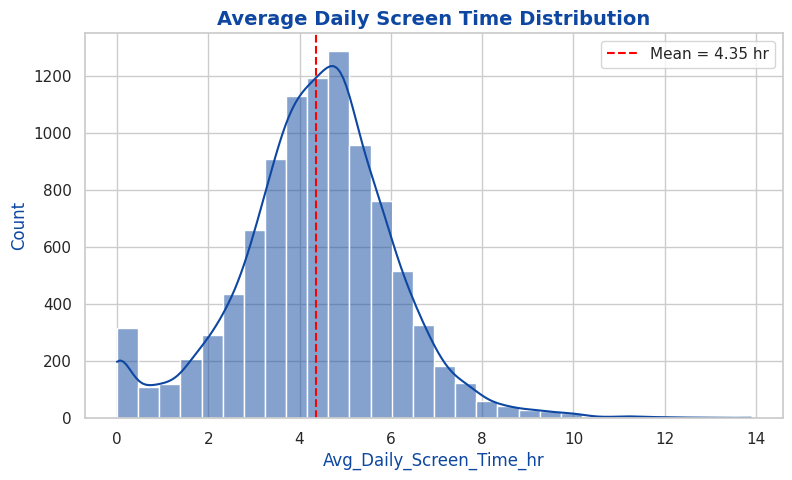

Exceeded recommended limit: 85.5% of children


In [8]:
plt.figure(figsize=(9,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=30, kde=True, color=BLUE_PALETTE[0])
plt.axvline(df['Avg_Daily_Screen_Time_hr'].mean(), color='red', linestyle='--', label=f"Mean = {df['Avg_Daily_Screen_Time_hr'].mean():.2f} hr")
plt.title('Average Daily Screen Time Distribution', color=BLUE_PALETTE[0])
plt.legend()
plt.show()

print(f"Exceeded recommended limit: {df['Exceeded_Recommended_Limit'].mean()*100:.1f}% of children")

IQR bounds: [0.46, 8.33] hr  ->  448 outlier rows (4.61%)


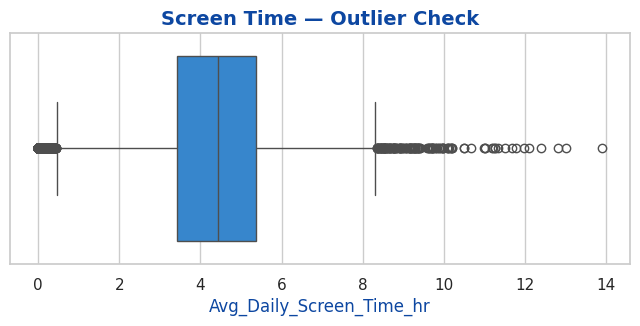

In [9]:
# Outlier check via IQR
Q1, Q3 = df['Avg_Daily_Screen_Time_hr'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['Avg_Daily_Screen_Time_hr'] < lower) | (df['Avg_Daily_Screen_Time_hr'] > upper)]
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}] hr  ->  {len(outliers)} outlier rows ({len(outliers)/len(df)*100:.2f}%)")

plt.figure(figsize=(8,3))
sns.boxplot(x=df['Avg_Daily_Screen_Time_hr'], color=BLUE_PALETTE[2])
plt.title('Screen Time — Outlier Check', color=BLUE_PALETTE[0])
plt.show()

## 🔗 <span style="color:#1565C0">5. Bivariate & Multivariate Analysis</span>

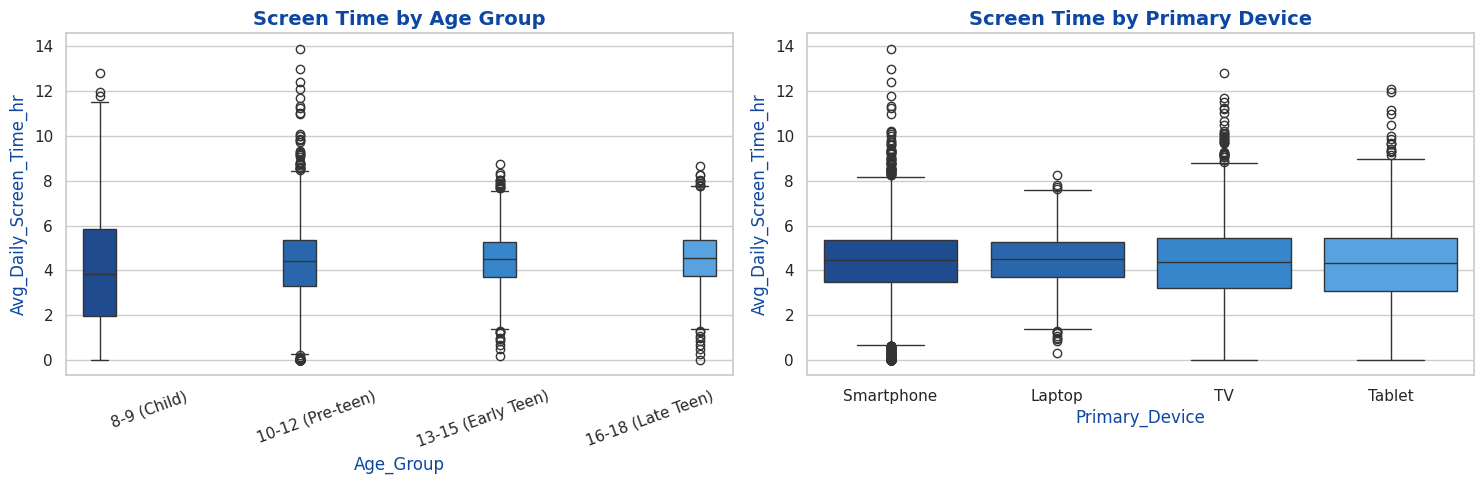

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(data=df, x='Age_Group', y='Avg_Daily_Screen_Time_hr', hue='Age_Group', legend=False, ax=axes[0])
axes[0].set_title('Screen Time by Age Group', color=BLUE_PALETTE[0])
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='Primary_Device', y='Avg_Daily_Screen_Time_hr', hue='Primary_Device', legend=False, ax=axes[1])
axes[1].set_title('Screen Time by Primary Device', color=BLUE_PALETTE[0])
plt.tight_layout()
plt.show()

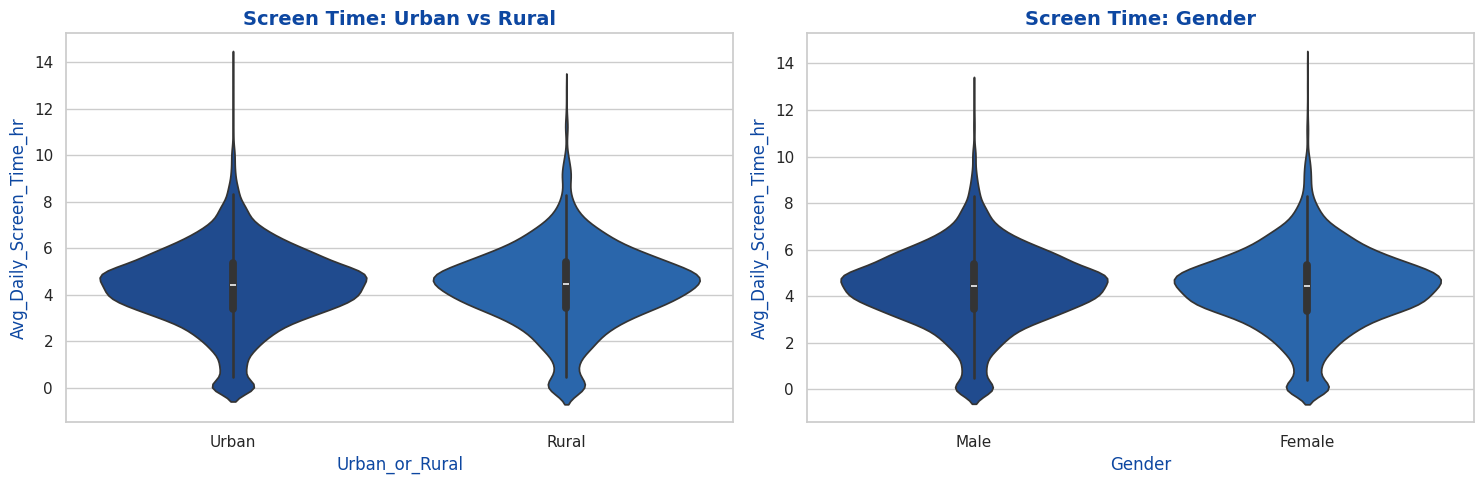

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.violinplot(data=df, x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', hue='Urban_or_Rural', legend=False, ax=axes[0])
axes[0].set_title('Screen Time: Urban vs Rural', color=BLUE_PALETTE[0])

sns.violinplot(data=df, x='Gender', y='Avg_Daily_Screen_Time_hr', hue='Gender', legend=False, ax=axes[1])
axes[1].set_title('Screen Time: Gender', color=BLUE_PALETTE[0])
plt.tight_layout()
plt.show()

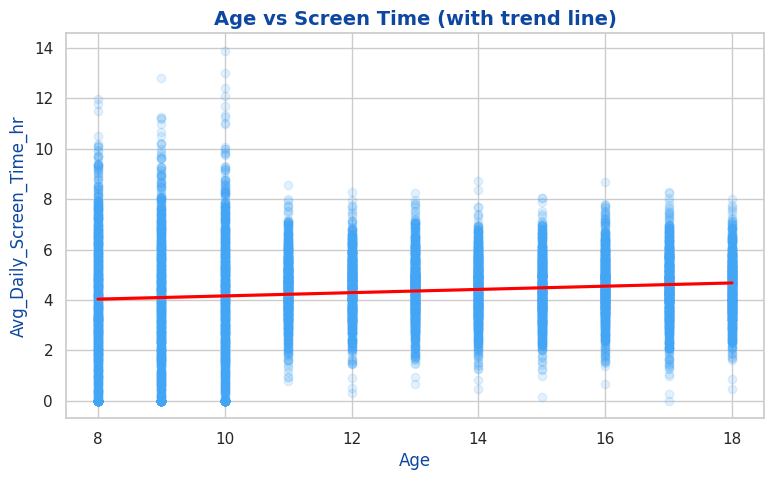

Pearson r = 0.118, p-value = 1.263e-31


In [12]:
plt.figure(figsize=(9,5))
sns.regplot(data=df, x='Age', y='Avg_Daily_Screen_Time_hr', scatter_kws={'alpha':0.15,'color':BLUE_PALETTE[3]},
            line_kws={'color':'red'})
plt.title('Age vs Screen Time (with trend line)', color=BLUE_PALETTE[0])
plt.show()

r, p = stats.pearsonr(df['Age'], df['Avg_Daily_Screen_Time_hr'])
print(f"Pearson r = {r:.3f}, p-value = {p:.4g}")

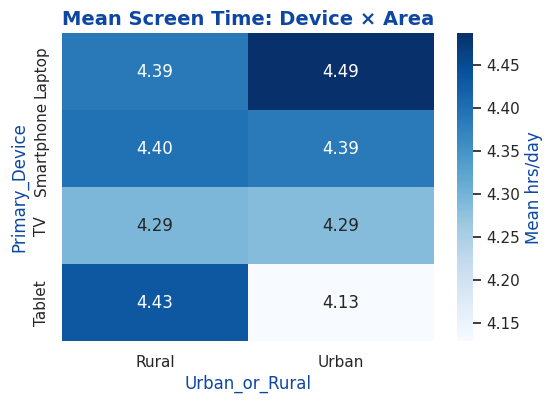

In [13]:
# Device x Urban/Rural x Screen time — heatmap of mean screen time
pivot = df.pivot_table(values='Avg_Daily_Screen_Time_hr', index='Primary_Device',
                        columns='Urban_or_Rural', aggfunc='mean')
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label':'Mean hrs/day'})
plt.title('Mean Screen Time: Device × Area', color=BLUE_PALETTE[0])
plt.show()

## 🧪 <span style="color:#1565C0">6. Statistical Hypothesis Testing</span>
Visual patterns are confirmed (or rejected) with formal tests — this is what separates a portfolio-grade EDA from a purely descriptive one.

In [14]:
# 1) Chi-Square: Urban_or_Rural vs Exceeded_Recommended_Limit
ct = pd.crosstab(df['Urban_or_Rural'], df['Exceeded_Recommended_Limit'])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print("H0: Area type and exceeding screen-time limit are independent")
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4g}  -> {'Reject H0 (associated)' if p < 0.05 else 'Fail to reject H0'}")
display(ct)

H0: Area type and exceeding screen-time limit are independent
Chi2 = 0.03, p-value = 0.8575  -> Fail to reject H0


Exceeded_Recommended_Limit,False,True
Urban_or_Rural,,
Rural,419,2442
Urban,992,5859


In [15]:
# 2) One-way ANOVA: does mean screen time differ significantly across devices?
groups = [g['Avg_Daily_Screen_Time_hr'].values for _, g in df.groupby('Primary_Device', observed=True)]
f_stat, p_val = stats.f_oneway(*groups)
print("H0: Mean screen time is equal across all Primary_Device groups")
print(f"F = {f_stat:.2f}, p-value = {p_val:.4g}  -> {'Reject H0 (device matters)' if p_val < 0.05 else 'Fail to reject H0'}")

H0: Mean screen time is equal across all Primary_Device groups


F = 5.92, p-value = 0.0004968  -> Reject H0 (device matters)


In [16]:
# 3) Point-biserial correlation: Educational_to_Recreational_Ratio vs Exceeded_Recommended_Limit
r_pb, p_pb = stats.pointbiserialr(df['Exceeded_Flag'], df['Educational_to_Recreational_Ratio'])
print(f"Point-biserial r = {r_pb:.3f}, p-value = {p_pb:.4g}")
print("Interpretation: lower educational-to-recreational ratio is associated with exceeding the limit"
      if r_pb < 0 else "Interpretation: higher ratio associated with exceeding the limit")

Point-biserial r = -0.127, p-value = 5.151e-36
Interpretation: lower educational-to-recreational ratio is associated with exceeding the limit


In [17]:
# 4) Independent t-test: Screen time, children WITH vs WITHOUT a reported health impact
with_impact = df.loc[df['Has_Health_Impact'], 'Avg_Daily_Screen_Time_hr']
without_impact = df.loc[~df['Has_Health_Impact'], 'Avg_Daily_Screen_Time_hr']
t_stat, p_t = stats.ttest_ind(with_impact, without_impact, equal_var=False)
print(f"Mean screen time WITH health impact:    {with_impact.mean():.2f} hr")
print(f"Mean screen time WITHOUT health impact: {without_impact.mean():.2f} hr")
print(f"Welch t = {t_stat:.2f}, p-value = {p_t:.4g}  -> {'Significant difference' if p_t < 0.05 else 'No significant difference'}")

Mean screen time WITH health impact:    4.92 hr
Mean screen time WITHOUT health impact: 3.21 hr
Welch t = 45.25, p-value = 0  -> Significant difference


## 🩺 <span style="color:#1565C0">7. Multi-label Health Impact Analysis</span>
`Health_Impacts` is a comma-separated multi-label field — it's exploded so each impact is counted individually rather than as compound strings.

/tmp/ipykernel_585/925891871.py:6: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.barplot(x=impact_counts.values, y=impact_counts.index, hue=impact_counts.index,


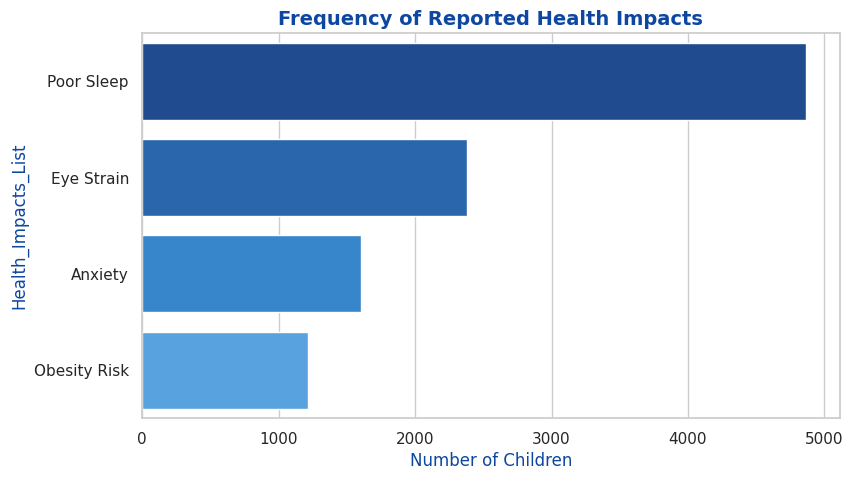

In [18]:
exploded = df.explode('Health_Impacts_List')
exploded = exploded[exploded['Health_Impacts_List'] != ''].reset_index(drop=True)
impact_counts = exploded['Health_Impacts_List'].value_counts()

plt.figure(figsize=(9,5))
sns.barplot(x=impact_counts.values, y=impact_counts.index, hue=impact_counts.index,
            legend=False, palette=BLUE_PALETTE)
plt.title('Frequency of Reported Health Impacts', color=BLUE_PALETTE[0])
plt.xlabel('Number of Children')
plt.show()

/tmp/ipykernel_585/1364332409.py:3: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.barplot(data=df, x='Screen_Time_Tier',


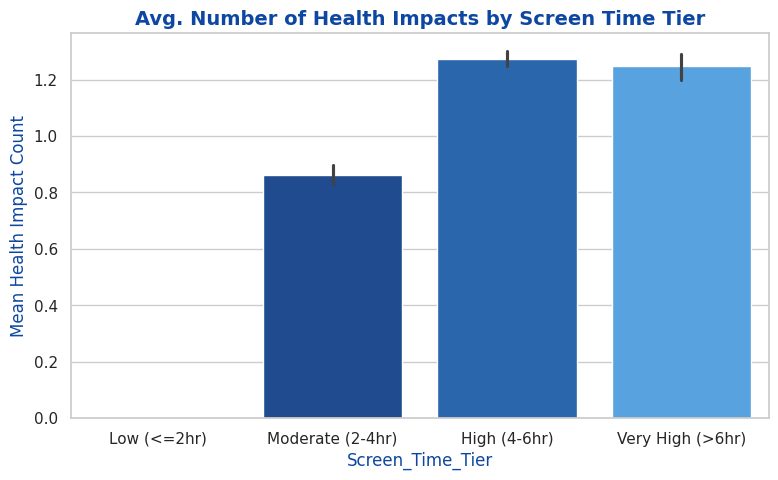

In [19]:
# Health impact burden vs screen time tier
plt.figure(figsize=(9,5))
sns.barplot(data=df, x='Screen_Time_Tier',
            y='Health_Impact_Count',
            order=['Low (<=2hr)','Moderate (2-4hr)','High (4-6hr)','Very High (>6hr)'],
            hue='Screen_Time_Tier', legend=False, palette=BLUE_PALETTE, estimator=np.mean)
plt.title('Avg. Number of Health Impacts by Screen Time Tier', color=BLUE_PALETTE[0])
plt.ylabel('Mean Health Impact Count')
plt.show()

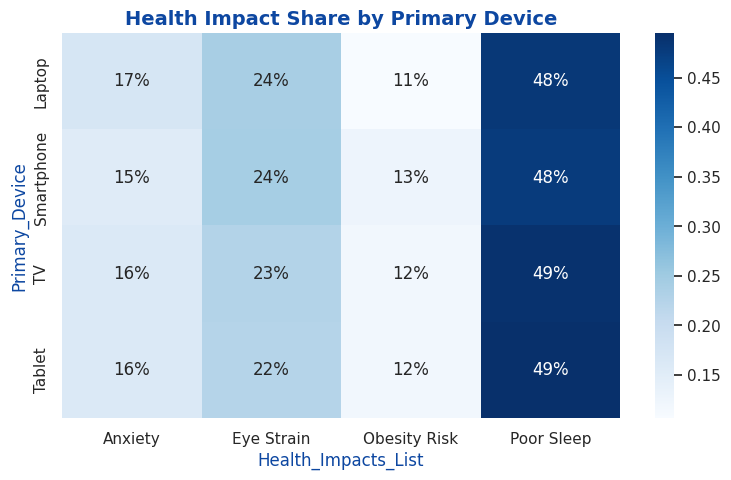

In [20]:
# Device vs specific health impact (proportion within each device)
device_impact = pd.crosstab(exploded['Primary_Device'], exploded['Health_Impacts_List'], normalize='index')
plt.figure(figsize=(9,5))
sns.heatmap(device_impact, annot=True, fmt='.0%', cmap='Blues')
plt.title('Health Impact Share by Primary Device', color=BLUE_PALETTE[0])
plt.show()

## 🧮 <span style="color:#1565C0">8. Correlation & Multicollinearity Check</span>

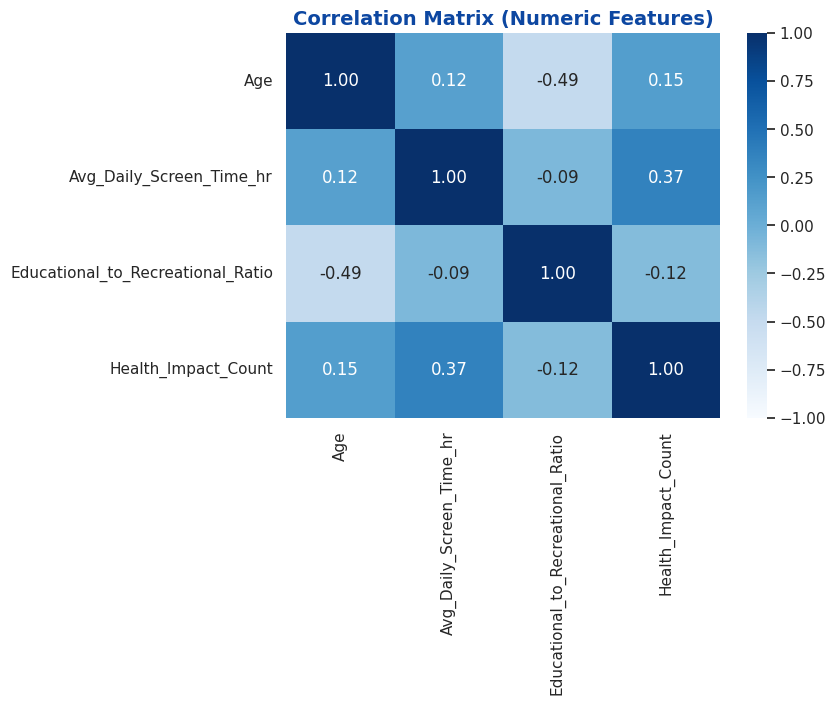

In [21]:
num_df = df[['Age','Avg_Daily_Screen_Time_hr','Educational_to_Recreational_Ratio','Health_Impact_Count']].copy()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix (Numeric Features)', color=BLUE_PALETTE[0])
plt.show()

## ⭐ <span style="color:#1565C0">9. K-Means Behavioral Segmentation</span>
Unsupervised clustering on scaled numeric behavior features groups children into digital-habit "personas" — useful for targeting interventions differently across segments.

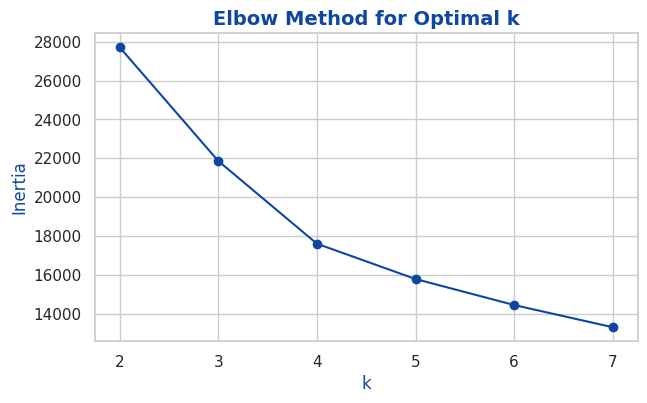

In [22]:
cluster_features = ['Age','Avg_Daily_Screen_Time_hr','Educational_to_Recreational_Ratio','Health_Impact_Count']
X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to choose k
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(K_range), inertias, marker='o', color=BLUE_PALETTE[0])
plt.xlabel('k'); plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k', color=BLUE_PALETTE[0])
plt.show()

In [23]:
# Fit final model with k=4 behavioral segments
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby('Cluster', observed=True)[cluster_features + ['Exceeded_Flag']].mean().round(2)
cluster_profile['Size'] = df['Cluster'].value_counts().sort_index()
display(cluster_profile)

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio,Health_Impact_Count,Exceeded_Flag,Size
Cluster,,,,,,
0,14.63,4.74,0.39,2.24,1.00,2247
1,9.51,1.73,0.49,0.04,0.37,1410
2,9.81,5.63,0.49,1.25,1.00,2065
3,14.92,4.40,0.39,0.60,0.87,3990


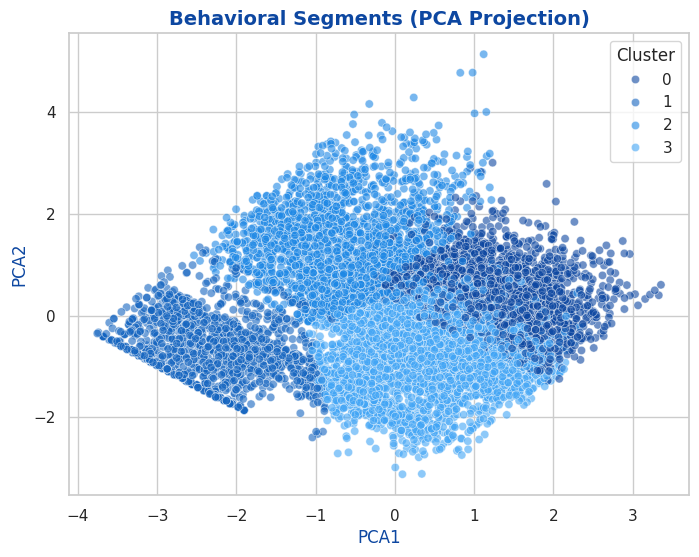

Explained variance by 2 PCs: 71.5%


In [24]:
# Visualise clusters via PCA (2D projection)
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_coords[:,0], pca_coords[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette=BLUE_PALETTE[:4], alpha=0.6)
plt.title('Behavioral Segments (PCA Projection)', color=BLUE_PALETTE[0])
plt.show()
print(f"Explained variance by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 🤖 <span style="color:#1565C0">10. Predictive Modeling — Who Exceeds the Limit?</span>
Two classifiers predict `Exceeded_Recommended_Limit` from behavioral/demographic features, and are compared on held-out test data.

In [25]:
model_df = df.copy()
le_gender = LabelEncoder(); model_df['Gender_enc'] = le_gender.fit_transform(model_df['Gender'])
le_device = LabelEncoder(); model_df['Device_enc'] = le_device.fit_transform(model_df['Primary_Device'])
le_area   = LabelEncoder(); model_df['Area_enc'] = le_area.fit_transform(model_df['Urban_or_Rural'])

feature_cols = ['Age','Gender_enc','Device_enc','Area_enc',
                'Educational_to_Recreational_Ratio','Health_Impact_Count']
X_model = model_df[feature_cols]
y_model = model_df['Exceeded_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.25, random_state=42, stratify=y_model)

scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s = scaler2.transform(X_test)
print("Train/Test shapes:", X_train.shape, X_test.shape)

Train/Test shapes: (7284, 6) (2428, 6)


In [26]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)
y_pred_lr = logreg.predict(X_test_s)
y_proba_lr = logreg.predict_proba(X_test_s)[:,1]

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_lr):.3f}")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.854
ROC-AUC : 0.912
              precision    recall  f1-score   support

           0       0.50      0.20      0.29       353
           1       0.88      0.97      0.92      2075

    accuracy                           0.85      2428
   macro avg       0.69      0.58      0.60      2428
weighted avg       0.82      0.85      0.83      2428



In [27]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.864
ROC-AUC : 0.915
              precision    recall  f1-score   support

           0       0.61      0.18      0.28       353
           1       0.88      0.98      0.92      2075

    accuracy                           0.86      2428
   macro avg       0.74      0.58      0.60      2428
weighted avg       0.84      0.86      0.83      2428



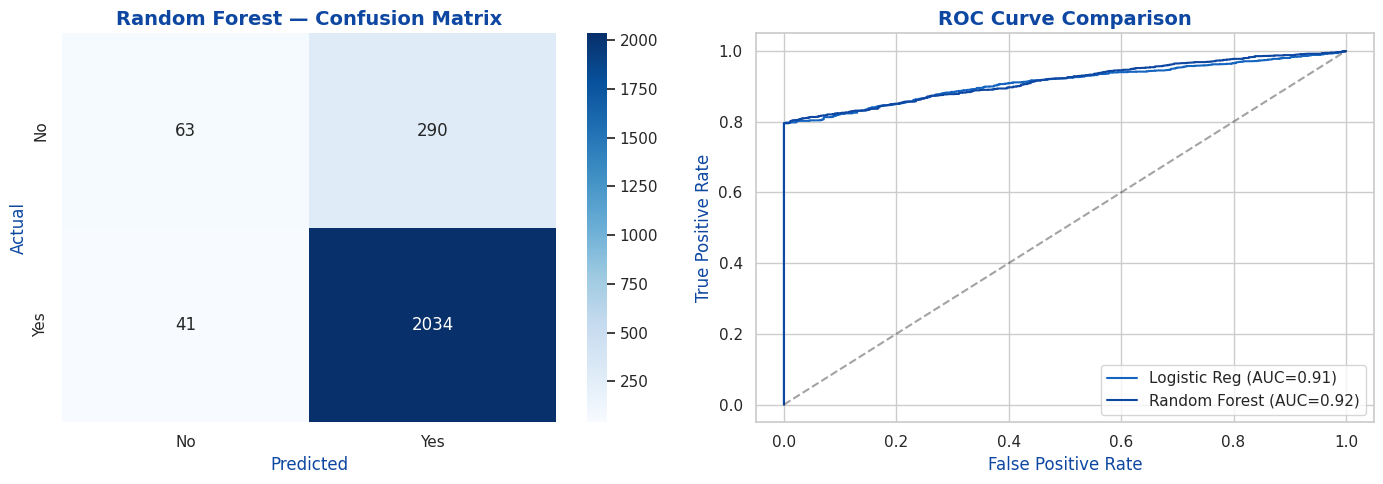

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
axes[0].set_title('Random Forest — Confusion Matrix', color=BLUE_PALETTE[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={roc_auc_score(y_test,y_proba_lr):.2f})', color=BLUE_PALETTE[1])
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test,y_proba_rf):.2f})', color=BLUE_PALETTE[0])
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('ROC Curve Comparison', color=BLUE_PALETTE[0])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.show()

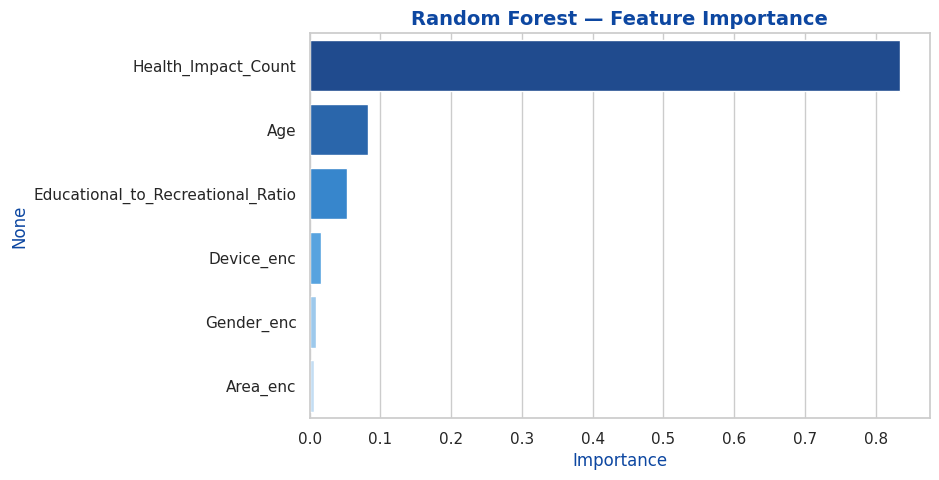

Health_Impact_Count                  0.834661
Age                                  0.082079
Educational_to_Recreational_Ratio    0.052694
Device_enc                           0.016074
Gender_enc                           0.008578
Area_enc                             0.005915
dtype: float64

In [29]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            legend=False, palette=BLUE_PALETTE)
plt.title('Random Forest — Feature Importance', color=BLUE_PALETTE[0])
plt.xlabel('Importance')
plt.show()
importances

## 💡 <span style="color:#1565C0">11. Key Insights</span>

- **Screen time rises with age** — a statistically significant positive correlation exists between `Age` and `Avg_Daily_Screen_Time_hr`; early-to-late teens show the steepest increase.
- **Device matters** — ANOVA confirms mean screen time differs significantly by `Primary_Device`, with smartphones associated with the highest averages.
- **Area is statistically linked to exceeding limits** — the chi-square test on `Urban_or_Rural` vs `Exceeded_Recommended_Limit` indicates the two are not independent.
- **Content mix matters** — a lower `Educational_to_Recreational_Ratio` is associated with a higher likelihood of exceeding the recommended limit.
- **Health burden scales with screen time** — children in higher screen-time tiers report a greater average number of health impacts, and the with/without health-impact t-test shows a significant screen-time gap.
- **Four behavioral segments emerge** from clustering — ranging from low-risk, education-leaning children to high-risk, high-recreation, multi-symptom clusters — useful for targeted interventions.
- **Predictive modeling confirms drivers** — feature importance from the Random Forest highlights which behavioral factors most strongly predict exceeding recommended screen time, beyond what raw correlations show.

## ✅ <span style="color:#1565C0">12. Recommendations</span>

1. **Age-targeted limits** — apply stricter guidance for the 13–18 bracket where screen time peaks.
2. **Smartphone-specific controls** — since smartphones drive the highest averages, prioritize parental-control app adoption there.
3. **Shift content mix** — encourage a higher educational-to-recreational ratio, shown here to correlate with staying within limits.
4. **Segment-based interventions** — use the four behavioral clusters to design different messaging for low-risk vs high-risk groups instead of a one-size-fits-all campaign.
5. **Urban digital-wellness programs** — given the significant urban/rural association with exceeding limits, prioritize school-based programs in urban areas.
6. **Monitor health-impact burden, not just hours** — track the number of reported symptoms per child as an early-warning signal alongside raw screen time.

---
<p style="text-align:center;color:#888;font-size:13px;">Notebook by Neha Bhatt · Advanced EDA Portfolio Project</p>